# RFM Analysis Notebook

This notebook performs RFM (Recency, Frequency, Monetary) analysis on customer transaction data.

---
## Section 1: Imports & Setup

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import datetime as dt
import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns",None)


---
## Section 2: RFM Calculator

    1. R - Recency : How recently a customer has made a purchase
    2. F - Frequency : How often a customer makes a purchase
    3. M - Monetory : How much money a customer spends in total

In [160]:
data=pd.read_csv(r"C:\Users\SNEHANGSHU\Desktop\sales-performance-analysis\RFM_analysis\data\superstore_clean.csv")

In [161]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Month_Name,Profit_Margin_Pct,Ship_Lag_Days,Is_Loss,Discounted_Revenue
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,Nov,16.00,3,False,261.960000
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,Nov,30.00,3,False,731.940000
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,Jun,47.00,4,False,14.620000
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,Oct,-40.00,7,True,526.667625
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,Oct,11.25,7,False,17.894400


In [162]:
data.shape

(9994, 29)

In [163]:
data.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year',
       'Month', 'Quarter', 'Month_Name', 'Profit_Margin_Pct', 'Ship_Lag_Days',
       'Is_Loss', 'Discounted_Revenue'],
      dtype='str')

### Columns needed for RFM Analysis grouped by CustomerID
     1. Recency - Order Date
     2. Frequency - Order ID
     3. Monetory - sale


In [164]:
# retaining the columns needed for the analysis
data=data[['Customer ID','Order ID', 'Order Date','Sales']]

#renameing the columns
data.rename(columns={"Order ID":"OrderID","Order Date":"OrderDate","Customer ID":"CustomerID"},inplace=True)

#data sample
data.head()

,CustomerID,OrderID,OrderDate,Sales
0,CG-12520,CA-2016-152156,2016-11-08,261.9600
1,CG-12520,CA-2016-152156,2016-11-08,731.9400
2,DV-13045,CA-2016-138688,2016-06-12,14.6200
3,SO-20335,US-2015-108966,2015-10-11,957.5775
4,SO-20335,US-2015-108966,2015-10-11,22.3680


In [165]:
#data type check
pd.DataFrame({"DataType":data.dtypes})

,DataType
CustomerID,str
OrderID,str
OrderDate,str
Sales,float64


In [166]:
# data typecasting
data['OrderDate']=pd.to_datetime(data["OrderDate"])

In [167]:
# Missing value and data type check after treatment
pd.DataFrame({'missing_values': data.isnull().sum(),
              'datatypes': data.dtypes})

,missing_values,datatypes
CustomerID,0,str
OrderID,0,str
OrderDate,0,datetime64[us]
Sales,0,float64


In [168]:
# data duplicates
print("Number of duplicated rows in the date before treatment", data.duplicated().sum())

# treating the duplciates
data = data.drop_duplicates(ignore_index=True)

# data duplicates after treating
print('Number of duplicated rows in the data after treatment:', data.duplicated().sum())


Number of duplicated rows in the date before treatment 2
Number of duplicated rows in the data after treatment: 0


In [169]:
data.head()

,CustomerID,OrderID,OrderDate,Sales
0,CG-12520,CA-2016-152156,2016-11-08,261.9600
1,CG-12520,CA-2016-152156,2016-11-08,731.9400
2,DV-13045,CA-2016-138688,2016-06-12,14.6200
3,SO-20335,US-2015-108966,2015-10-11,957.5775
4,SO-20335,US-2015-108966,2015-10-11,22.3680


In [170]:
# Maximum date of the Order from the dataset

# latest date of purchase from the entire data (billing close date)
data['OrderDate'].max()

Timestamp('2017-12-30 00:00:00')

In [171]:
# analytical date used for calculation

# analytical date = last purchased date + 1

analytical_date = data['OrderDate'].max() + dt.timedelta(days=1)
analytical_date

Timestamp('2017-12-31 00:00:00')

### RFM analysis

In [172]:
# Derive RFM
RFMScore=data.groupby("CustomerID").agg({"OrderDate":lambda x:(analytical_date-x.max()).days, # Recency
                                         "OrderID":lambda x: x.count(),                       # Frequency
                                         "Sales":lambda x:x.sum()                             # monetory
                                         })

RFMScore.rename(columns={"OrderDate":"Recency",
                         "OrderID":"Frequency",
                         "Sales":"Monetory"},inplace= True)

RFMScore.reset_index().head()

,CustomerID,Recency,Frequency,Monetory
0,AA-10315,185,11,5563.560
1,AA-10375,20,15,1056.390
2,AA-10480,260,12,1790.512
3,AA-10645,56,18,5086.935
4,AB-10015,416,6,886.156


In [173]:
# For RFM,
    # lower the value of recency more valuable the customer can be.
    # higher the value of frequency and monetory more valuable the customer can be.

# min and max for each attributes

for col in RFMScore:
    print(f"{col}: Min value is {RFMScore[col].min()} and Max value is {RFMScore[col].max()}")

Recency: Min value is 1 and Max value is 1166
Frequency: Min value is 1 and Max value is 37
Monetory: Min value is 4.833 and Max value is 25043.05


In [174]:
# Quantile for splitting the data

quantile=RFMScore.quantile(q=(0.25,0.50,0.75)).to_dict()
quantile

{'Recency': {0.25: 31.0, 0.5: 76.0, 0.75: 184.0},
 'Frequency': {0.25: 8.0, 0.5: 12.0, 0.75: 16.0},
 'Monetory': {0.25: 1146.0500000000002,
  0.5: 2256.3940000000002,
  0.75: 3785.276}}

In [175]:
# Function for the score ranks
# lower the value of recency more valuable the customer can be.
def recency_score(x,q,d):  # x: customer value, q: column_name, d: quantile_dataframe
    if x <= d[q][0.25]:
        return 1            #Highest Rank
    elif x <= d[q][0.50]:
        return 2
    elif x <= d[q][0.75]:
        return 3
    else:
        return 4           # lowest Rank

# higher the value of frequency and monetory more valuable the customer can be.
def FnM_score(x,q,d):   # x: customer value, q: column_name, d: quantile_dataframe
    if x <= d[q][0.25]:
        return 4           #lowest Rank
    elif x <= d[q][0.50]:
        return 3
    elif x <= d[q][0.75]:
        return 2
    else:
        return 1          # highest Rank

In [176]:
# columns to accomodate the function call
RFMScore["R_Rank"]=RFMScore["Recency"].apply(recency_score,args=("Recency",quantile,))
RFMScore["F_Rank"]=RFMScore["Frequency"].apply(FnM_score,args=("Frequency",quantile,))
RFMScore["M_Rank"]=RFMScore["Monetory"].apply(FnM_score,args=("Monetory",quantile,))

# RFM data sample
RFMScore.reset_index().head()

,CustomerID,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank
0,AA-10315,185,11,5563.560,4,3,1
1,AA-10375,20,15,1056.390,1,2,4
2,AA-10480,260,12,1790.512,4,3,3
3,AA-10645,56,18,5086.935,2,1,1
4,AB-10015,416,6,886.156,4,4,4


---
## Section 3: Segmentation



In [177]:
# Loyality Score (min: 3, max: 12)
RFMScore["LoyalityScore"]=RFMScore[["R_Rank","F_Rank","M_Rank"]].sum(axis=1)

RFMScore.head()

,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank,LoyalityScore
CustomerID,,,,,,,
AA-10315,185,11,5563.560,4,3,1,8
AA-10375,20,15,1056.390,1,2,4,7
AA-10480,260,12,1790.512,4,3,3,10
AA-10645,56,18,5086.935,2,1,1,4
AB-10015,416,6,886.156,4,4,4,12


In [178]:
# Loyalaity badge
badges = ['Platinum', 'Gold', 'Silver', 'Bronze']

score_cut=pd.qcut(RFMScore["LoyalityScore"],4,labels=badges)

RFMScore['LoyalityBadge'] = score_cut.values

RFMScore.head()

,Recency,Frequency,Monetory,R_Rank,F_Rank,M_Rank,LoyalityScore,LoyalityBadge
CustomerID,,,,,,,,
AA-10315,185,11,5563.560,4,3,1,8,Gold
AA-10375,20,15,1056.390,1,2,4,7,Gold
AA-10480,260,12,1790.512,4,3,3,10,Silver
AA-10645,56,18,5086.935,2,1,1,4,Platinum
AB-10015,416,6,886.156,4,4,4,12,Bronze


In [179]:
# segmented data
segmented_data = RFMScore.reset_index()
segmented_data = segmented_data[['CustomerID', 'Recency', 'Frequency', 'Monetory', 'LoyalityBadge']]

# Mapped data sample
segmented_data.head()

,CustomerID,Recency,Frequency,Monetory,LoyalityBadge
0,AA-10315,185,11,5563.560,Gold
1,AA-10375,20,15,1056.390,Gold
2,AA-10480,260,12,1790.512,Silver
3,AA-10645,56,18,5086.935,Platinum
4,AB-10015,416,6,886.156,Bronze


---
## Section 4: Visualizations



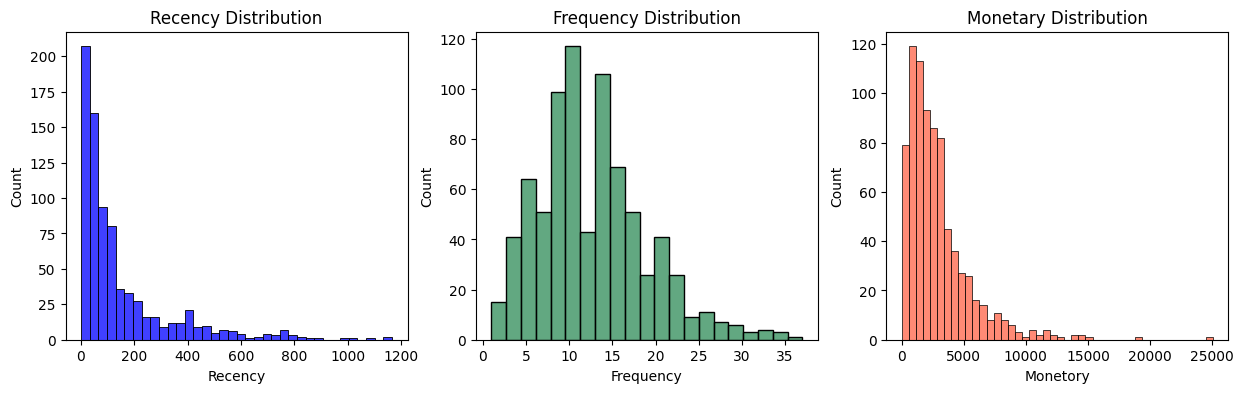

In [180]:
# Distribution of each RFM component
fig,axes=plt.subplots(1,3,figsize=(15,4))

sns.histplot(segmented_data["Recency"],ax=axes[0],color='blue')
sns.histplot(segmented_data["Frequency"],ax=axes[1],color='Seagreen')
sns.histplot(segmented_data["Monetory"],ax=axes[2],color='tomato')

axes[0].set_title('Recency Distribution')
axes[1].set_title('Frequency Distribution')
axes[2].set_title('Monetary Distribution')

plt.show()


#### Recency
- Most customers purchased very recently (0–100 days), with the count dropping sharply after that. A long tail extends to 1200 days, meaning a small group of lapsed/inactive customers haven't bought in years.
#### Frequency
- Follows a bell-shaped distribution peaking around 10–15 orders. Most customers are moderately frequent buyers, with very few placing more than 25 orders.
#### Monetary
- Heavily right-skewed majority of customers spend between $0–$2,500, while a small group of high-value customers spend up to $25,000. Classic pattern in retail data.

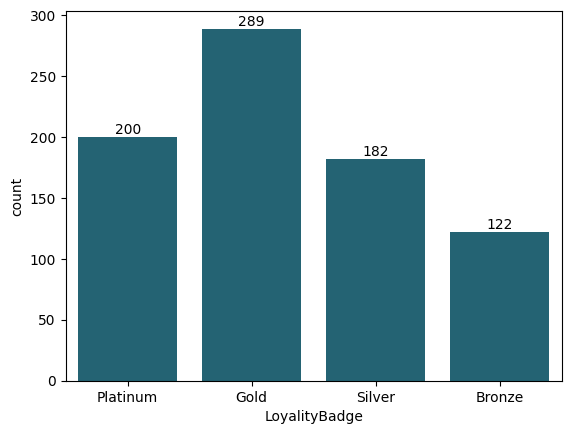

In [189]:
# How many customers in each badge
ax=sns.countplot(x='LoyalityBadge', data=segmented_data,
              order=['Platinum','Gold','Silver','Bronze'],color="#176b80")

ax.bar_label(ax.containers[0])
plt.show()


#### Loyalty Badge Insights

- Over **60% of customers** fall in Gold or Platinum tier — healthy loyalty base
- **Gold is the dominant segment** (289 customers) — potential to convert to Platinum
- **Bronze customers (122)** are the priority for win-back campaigns


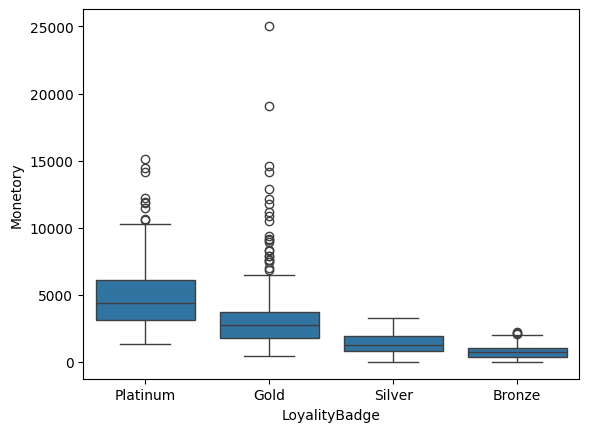

In [182]:
# Monetary value spread per badge
sns.boxplot(x='LoyalityBadge', y='Monetory', data=segmented_data,
            order=['Platinum','Gold','Silver','Bronze'])

plt.show()

#### Monetary Distribution by Badge

- Gold tier contains the **highest single spender (~$25K)** — review for Platinum upgrade
- Bronze customers are **consistently low spenders** with little variation
- Outliers in Platinum suggest **VIP customers** worth special attention

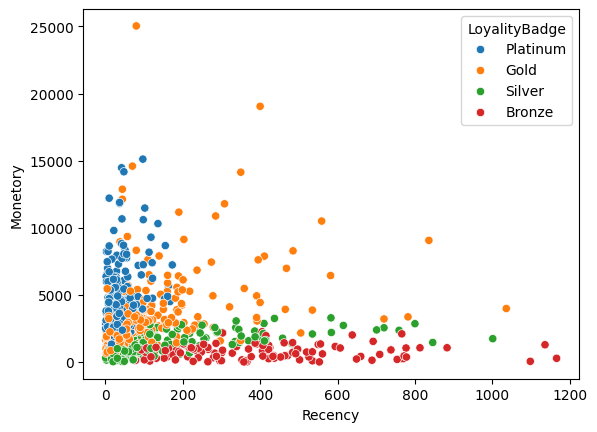

In [183]:
sns.scatterplot(x='Recency', y='Monetory',
                hue='LoyalityBadge', data=segmented_data)
plt.show()

In [184]:
# import matplotlib
# cmaps=matplotlib.colormaps()
# cmaps

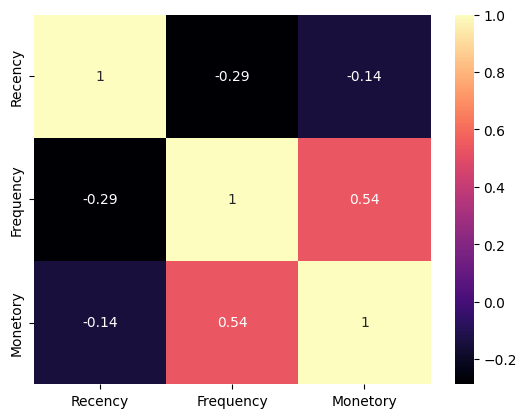

In [185]:
sns.heatmap(RFMScore[['Recency','Frequency','Monetory']].corr(),
            annot=True, cmap='magma')

plt.show()

#### Correlation Insights

| Finding | Value | Action |
|---|---|---|
| Frequent buyers spend more | 0.54 | Target frequent buyers for upsell |
| Recency barely affects spend | -0.14 | Don't ignore lapsed high-spenders |
| Recent = slightly more frequent | -0.29 | Re-engage lapsed to boost frequency |

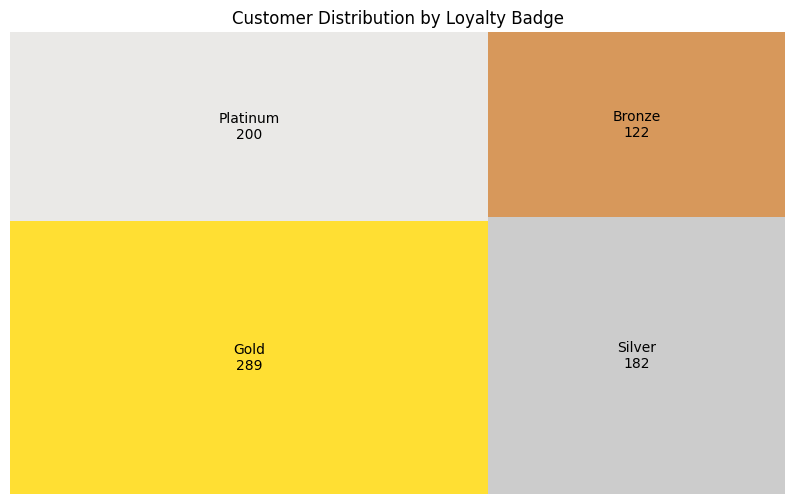

In [196]:
# Define badge_counts first
badge_counts = segmented_data['LoyalityBadge'].value_counts()

# Treemap
plt.figure(figsize=(10, 6))
# Match colors to actual badge names
color_map = {
    'Platinum' : '#e5e4e2',   # platinum grey
    'Gold'     : 'gold',       # gold yellow
    'Silver'   : '#C0C0C0',   # silver grey
    'Bronze'   : '#cd7f32'    # bronze brown
}

colors = [color_map[badge] for badge in badge_counts.index]

squarify.plot(
    sizes  = badge_counts.values,
    label  = [f"{b}\n{c}" for b, c in zip(badge_counts.index, badge_counts.values)],
    color  = colors,
    alpha  = 0.8
)
plt.title('Customer Distribution by Loyalty Badge')
plt.axis('off')
plt.show()

---
## Section 5: Export


- `segmented_data.csv` - Segment-level summary statistics

In [187]:
segmented_data.to_csv(r"C:\Users\SNEHANGSHU\Desktop\sales-performance-analysis\RFM_analysis\data\RFM analysis output data\segmented_data.csv")